In [148]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error)

from xgboost import XGBRegressor

### DPW

In [149]:
dpw_no2_train = pd.read_csv("ML ready dppm no2 datasets/dpw_no2_train.csv")
dpw_no2_train["datetime_utc"] = pd.to_datetime(dpw_no2_train["datetime_utc"])
dpw_no2_test = pd.read_csv("ML ready dpp no2 datasets/dpw_no2_test.csv")
dpw_no2_test["datetime_utc"] = pd.to_datetime(dpw_no2_test["datetime_utc"])

In [150]:
predictor_cols = [
    "co_wrk_aux",
    "no2_wrk_aux",
    "no_wrk_aux",
    "o3_wrk_aux",
    "rh",
    "temp"
]

X_train = dpw_no2_train[predictor_cols]
y_train = dpw_no2_train["dpw_quant_no2"]

In [151]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_train)

In [152]:
r2 = r2_score(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_pred))

print(f"R^2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.9909
MAE: 0.4164
RMSE: 0.5508


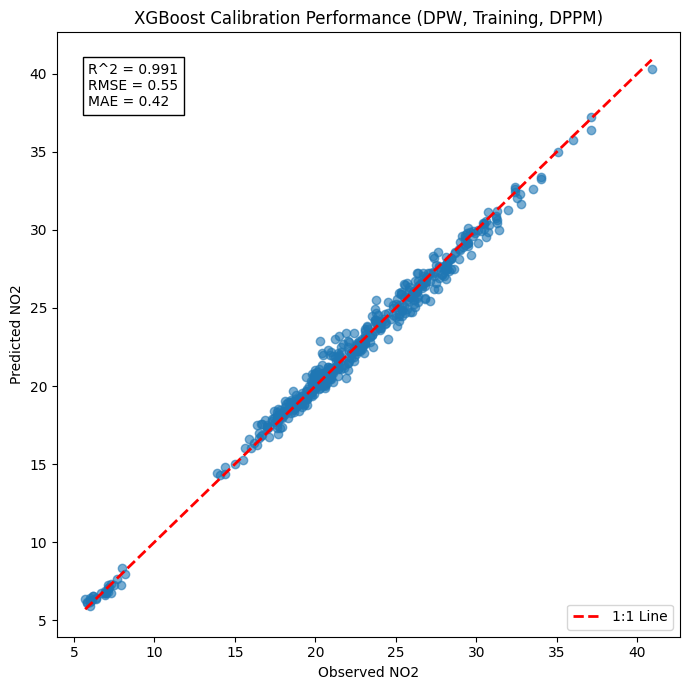

In [153]:
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_pred, alpha=0.6)

min_val = min(y_train.min(), y_pred.min())
max_val = max(y_train.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="1:1 Line")

plt.xlabel("Observed NO2")
plt.ylabel("Predicted NO2")
plt.title("XGBoost Calibration Performance (DPW, Training, DPPM)")

plt.text(0.05, 0.95, f"R^2 = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}", transform=plt.gca().transAxes, verticalalignment="top", bbox=dict(facecolor="white"))

plt.legend()
plt.tight_layout()
plt.show()

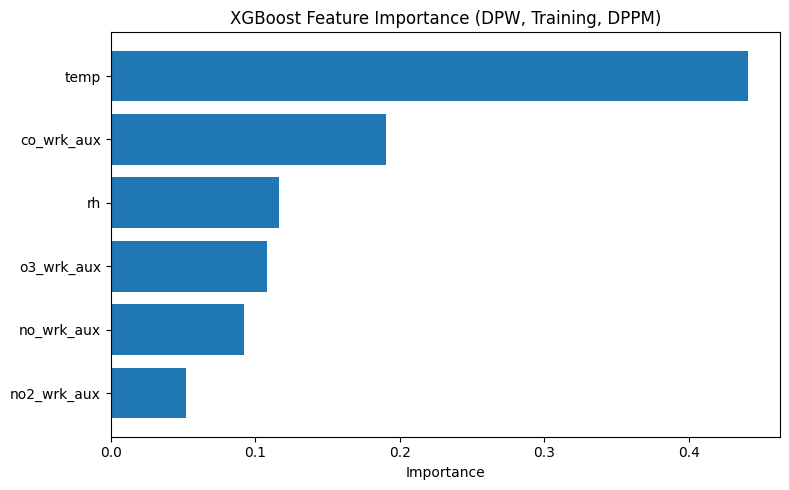

In [154]:
importance = pd.DataFrame({"feature": X_train.columns,"importance": model.feature_importances_})

importance = importance.sort_values(by="importance",ascending=True)

plt.figure(figsize=(8,5))

plt.barh(importance["feature"], importance["importance"])

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (DPW, Training, DPPM)")

plt.tight_layout()
plt.show()

In [155]:
predictor_cols = [
    "co_wrk_aux",
    "no2_wrk_aux",
    "no_wrk_aux",
    "o3_wrk_aux",
    "rh",
    "temp"
]

X_test = dpw_no2_test[predictor_cols]
y_test = dpw_no2_test["dpw_quant_no2"]

In [156]:
y_pred = model.predict(X_test)

In [157]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.4464
MAE: 2.8316
RMSE: 3.9544


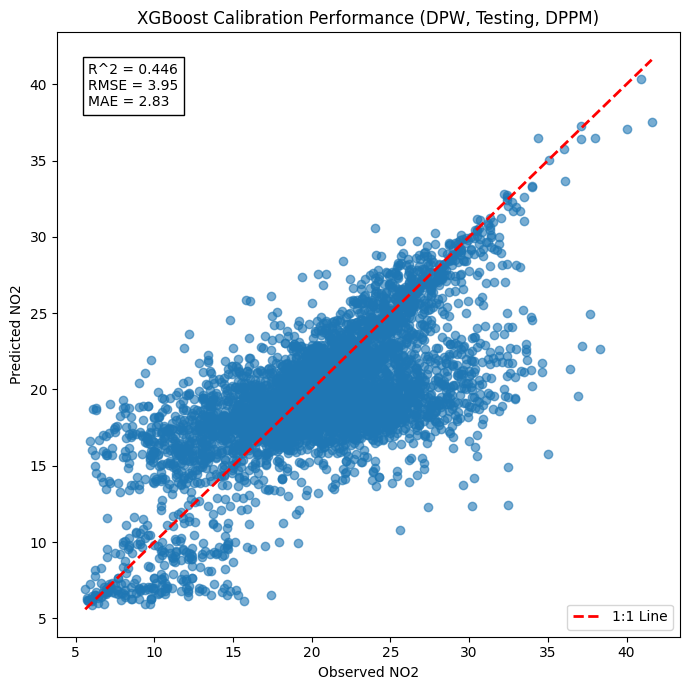

In [158]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="1:1 Line")

plt.xlabel("Observed NO2")
plt.ylabel("Predicted NO2")
plt.title("XGBoost Calibration Performance (DPW, Testing, DPPM)")

plt.text(0.05, 0.95, f"R^2 = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}", transform=plt.gca().transAxes, verticalalignment="top", bbox=dict(facecolor="white"))

plt.legend()
plt.tight_layout()
plt.show()

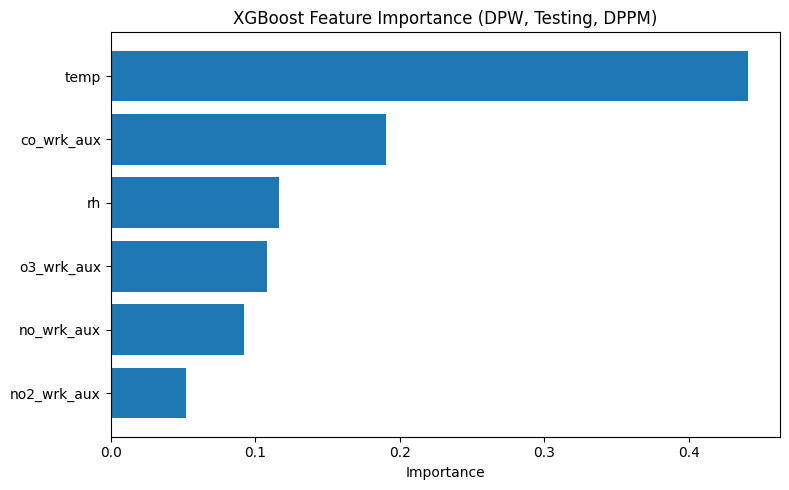

In [159]:
importance = pd.DataFrame({"feature": X_train.columns,"importance": model.feature_importances_})

importance = importance.sort_values(by="importance",ascending=True)

plt.figure(figsize=(8,5))

plt.barh(importance["feature"], importance["importance"])

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (DPW, Testing, DPPM)")

plt.tight_layout()
plt.show()

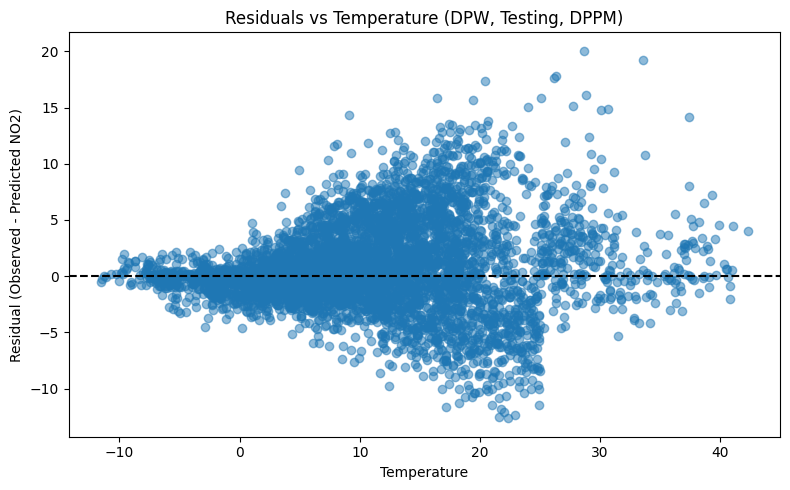

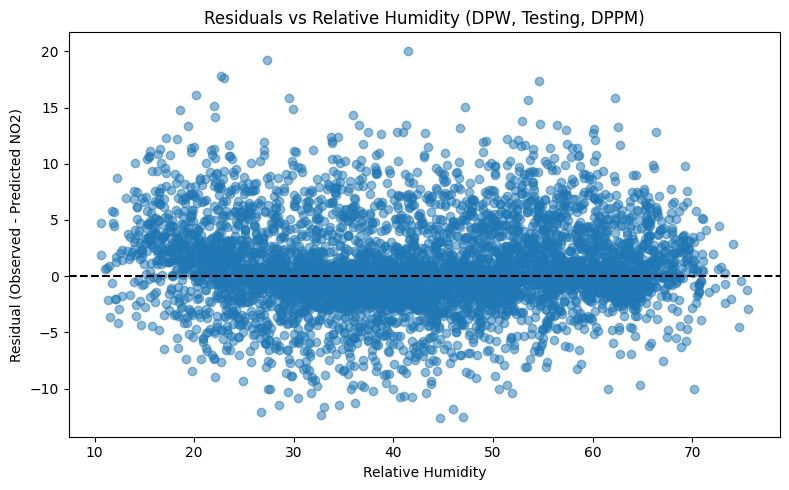

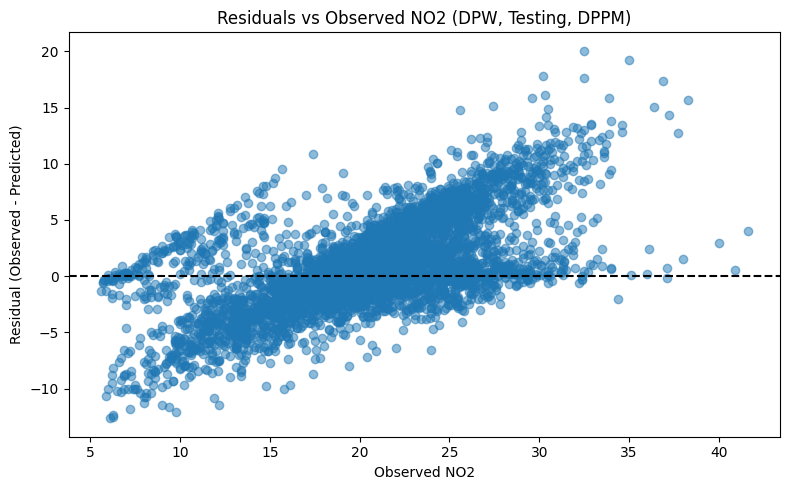

In [160]:
results = X_test.copy()

results["observed_no2"] = y_test.values
results["predicted_no2"] = y_pred

results["residual"] = results["observed_no2"] - results["predicted_no2"]

plt.figure(figsize=(8,5))

plt.scatter(results["temp"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Temperature")
plt.ylabel("Residual (Observed - Predicted NO2)")
plt.title("Residuals vs Temperature (DPW, Testing, DPPM)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(results["rh"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Relative Humidity")
plt.ylabel("Residual (Observed - Predicted NO2)")
plt.title("Residuals vs Relative Humidity (DPW, Testing, DPPM)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(results["observed_no2"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Observed NO2")
plt.ylabel("Residual (Observed - Predicted)")
plt.title("Residuals vs Observed NO2 (DPW, Testing, DPPM)")

plt.tight_layout()
plt.show()

### MJF

In [161]:
mjf_no2_train = pd.read_csv("ML ready dppm no2 datasets/mjf_no2_train.csv")
mjf_no2_train["datetime_utc"] = pd.to_datetime(mjf_no2_train["datetime_utc"])
mjf_no2_test = pd.read_csv("ML ready dpp no2 datasets/mjf_no2_test.csv")
mjf_no2_test["datetime_utc"] = pd.to_datetime(mjf_no2_test["datetime_utc"])

In [162]:
predictor_cols = [
    "co_wrk_aux",
    "no2_wrk_aux",
    "no_wrk_aux",
    "o3_wrk_aux",
    "rh",
    "temp"
]

X_train = mjf_no2_train[predictor_cols]
y_train = mjf_no2_train["mjf_quant_no2"]

In [163]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_train)

In [164]:
r2 = r2_score(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_pred))

print(f"R^2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.9920
MAE: 0.3733
RMSE: 0.4874


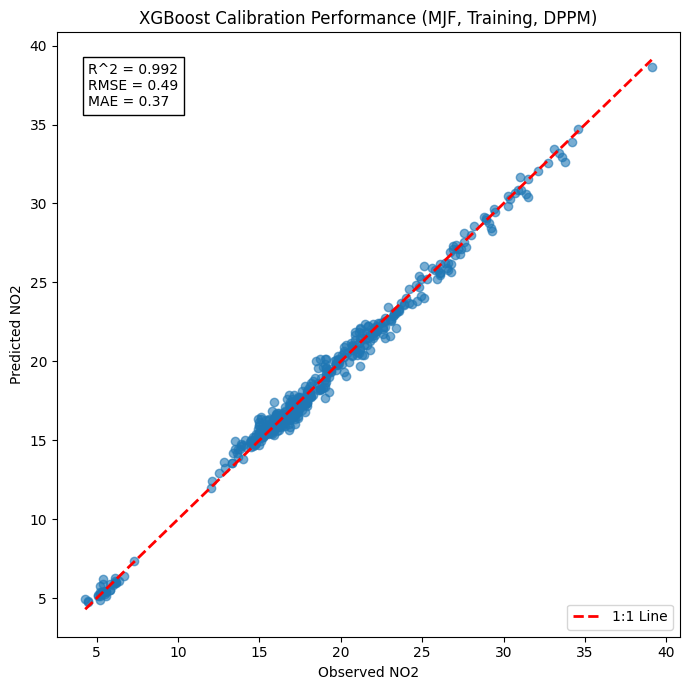

In [165]:
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_pred, alpha=0.6)

min_val = min(y_train.min(), y_pred.min())
max_val = max(y_train.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="1:1 Line")

plt.xlabel("Observed NO2")
plt.ylabel("Predicted NO2")
plt.title("XGBoost Calibration Performance (MJF, Training, DPPM)")

plt.text(0.05, 0.95, f"R^2 = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}", transform=plt.gca().transAxes, verticalalignment="top", bbox=dict(facecolor="white"))

plt.legend()
plt.tight_layout()
plt.show()

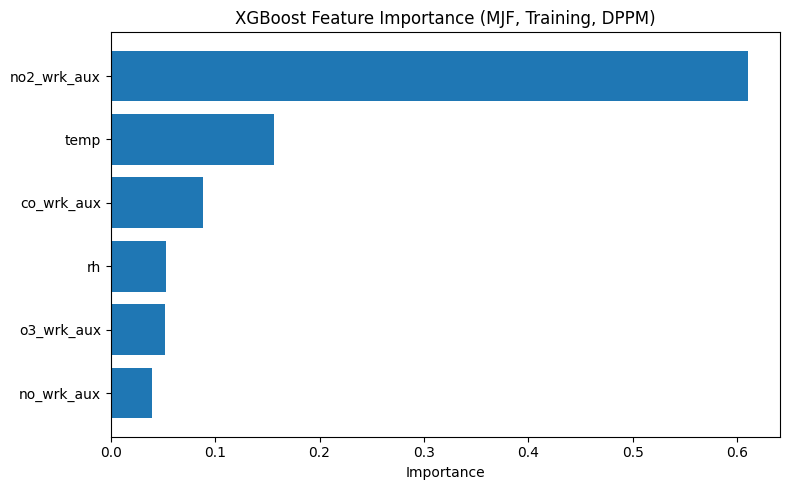

In [166]:
importance = pd.DataFrame({"feature": X_train.columns,"importance": model.feature_importances_})

importance = importance.sort_values(by="importance",ascending=True)

plt.figure(figsize=(8,5))

plt.barh(importance["feature"], importance["importance"])

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (MJF, Training, DPPM)")

plt.tight_layout()
plt.show()

In [167]:
predictor_cols = [
    "co_wrk_aux",
    "no2_wrk_aux",
    "no_wrk_aux",
    "o3_wrk_aux",
    "rh",
    "temp"
]

X_test = mjf_no2_test[predictor_cols]
y_test = mjf_no2_test["mjf_quant_no2"]

In [168]:
y_pred = model.predict(X_test)

In [169]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: -0.2073
MAE: 4.9085
RMSE: 6.2074


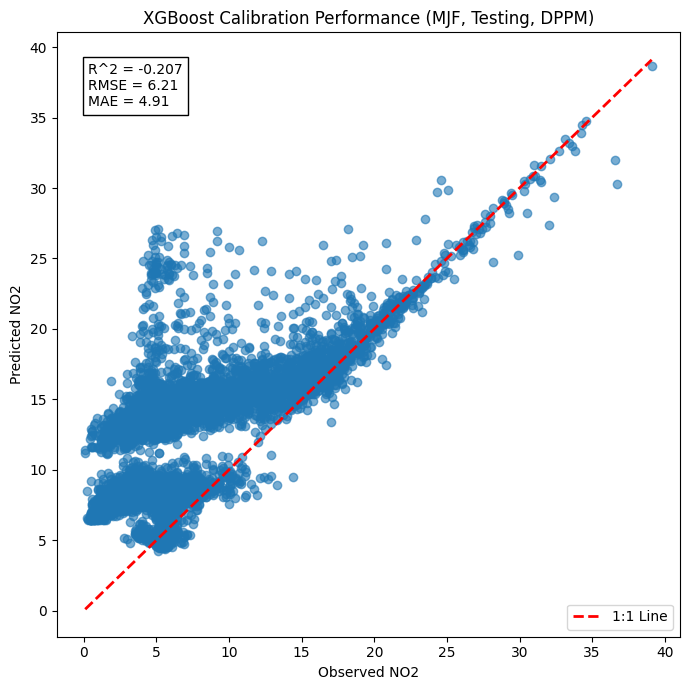

In [170]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="1:1 Line")

plt.xlabel("Observed NO2")
plt.ylabel("Predicted NO2")
plt.title("XGBoost Calibration Performance (MJF, Testing, DPPM)")

plt.text(0.05, 0.95, f"R^2 = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}", transform=plt.gca().transAxes, verticalalignment="top", bbox=dict(facecolor="white"))

plt.legend()
plt.tight_layout()
plt.show()

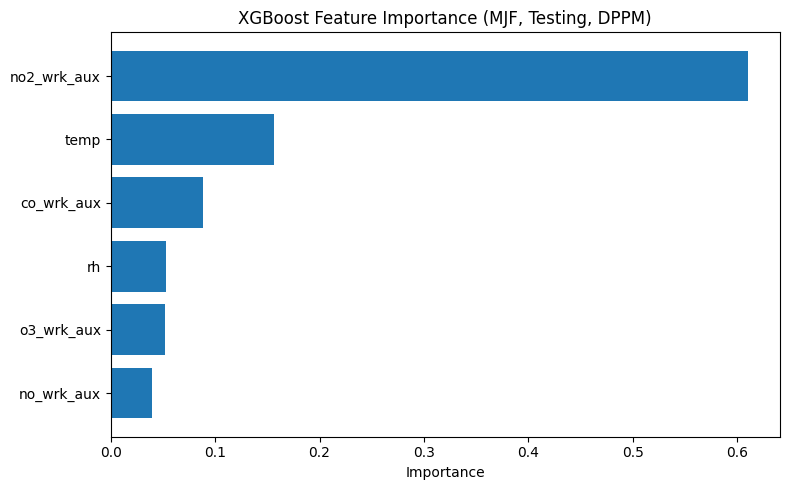

In [171]:
importance = pd.DataFrame({"feature": X_train.columns,"importance": model.feature_importances_})

importance = importance.sort_values(by="importance",ascending=True)

plt.figure(figsize=(8,5))

plt.barh(importance["feature"], importance["importance"])

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (MJF, Testing, DPPM)")

plt.tight_layout()
plt.show()

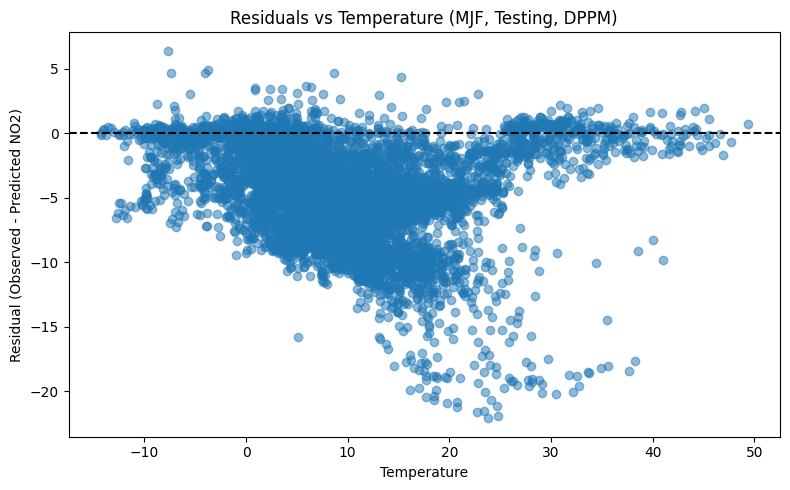

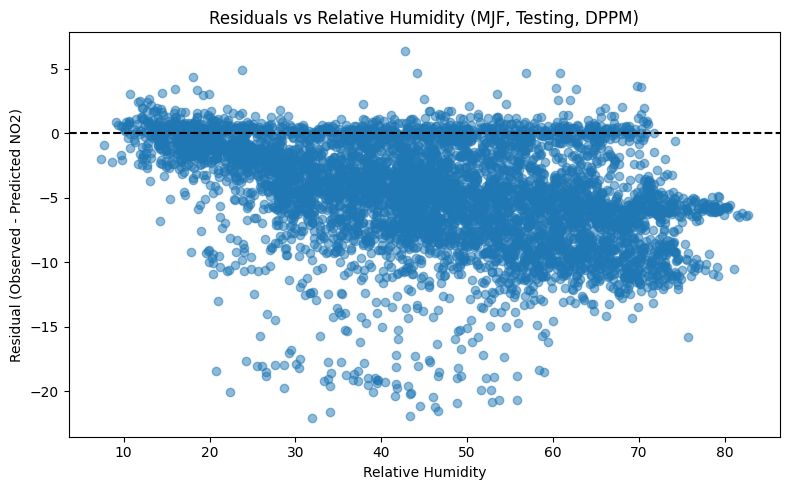

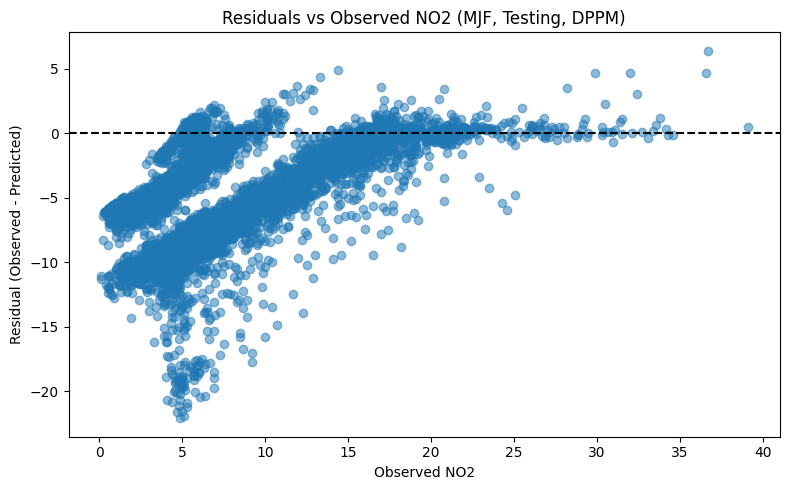

In [172]:
results = X_test.copy()

results["observed_no2"] = y_test.values
results["predicted_no2"] = y_pred

results["residual"] = results["observed_no2"] - results["predicted_no2"]

plt.figure(figsize=(8,5))

plt.scatter(results["temp"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Temperature")
plt.ylabel("Residual (Observed - Predicted NO2)")
plt.title("Residuals vs Temperature (MJF, Testing, DPPM)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(results["rh"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Relative Humidity")
plt.ylabel("Residual (Observed - Predicted NO2)")
plt.title("Residuals vs Relative Humidity (MJF, Testing, DPPM)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(results["observed_no2"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Observed NO2")
plt.ylabel("Residual (Observed - Predicted)")
plt.title("Residuals vs Observed NO2 (MJF, Testing, DPPM)")

plt.tight_layout()
plt.show()

### PEMA

In [173]:
pema_no2_train = pd.read_csv("ML ready dppm no2 datasets/pema_no2_train.csv")
pema_no2_train["datetime_utc"] = pd.to_datetime(pema_no2_train["datetime_utc"])
pema_no2_test = pd.read_csv("ML ready dpp no2 datasets/pema_no2_test.csv")
pema_no2_test["datetime_utc"] = pd.to_datetime(pema_no2_test["datetime_utc"])

In [174]:
predictor_cols = [
    "co_wrk_aux",
    "no2_wrk_aux",
    "no_wrk_aux",
    "o3_wrk_aux",
    "rh",
    "temp"
]

X_train = pema_no2_train[predictor_cols]
y_train = pema_no2_train["pema_quant_no2"]

In [175]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_train)

In [176]:
r2 = r2_score(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_pred))

print(f"R^2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.9960
MAE: 0.2855
RMSE: 0.3738


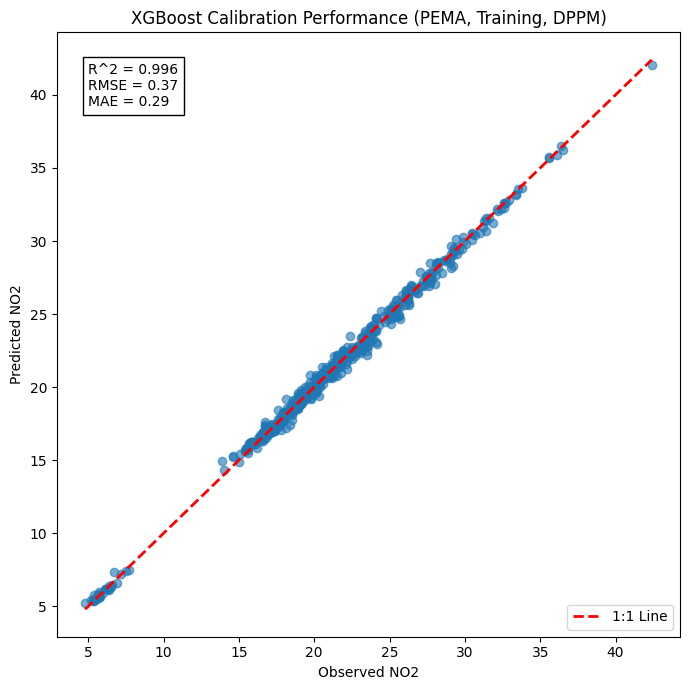

In [177]:
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_pred, alpha=0.6)

min_val = min(y_train.min(), y_pred.min())
max_val = max(y_train.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="1:1 Line")

plt.xlabel("Observed NO2")
plt.ylabel("Predicted NO2")
plt.title("XGBoost Calibration Performance (PEMA, Training, DPPM)")

plt.text(0.05, 0.95, f"R^2 = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}", transform=plt.gca().transAxes, verticalalignment="top", bbox=dict(facecolor="white"))

plt.legend()
plt.tight_layout()
plt.show()

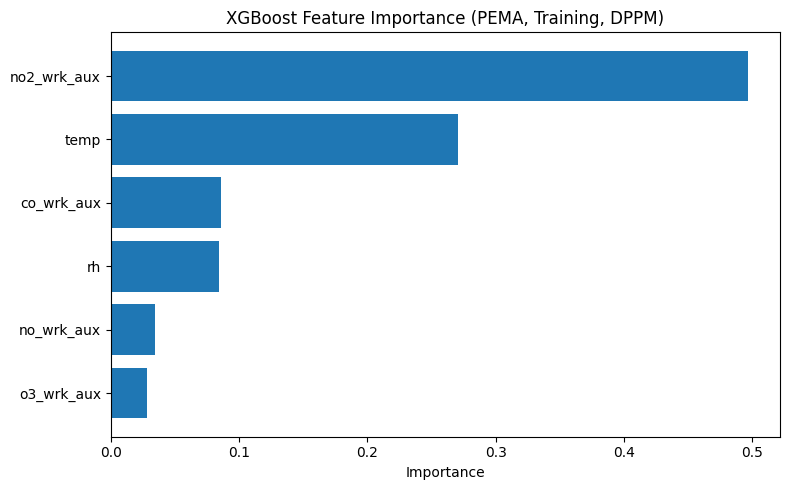

In [178]:
importance = pd.DataFrame({"feature": X_train.columns,"importance": model.feature_importances_})

importance = importance.sort_values(by="importance",ascending=True)

plt.figure(figsize=(8,5))

plt.barh(importance["feature"], importance["importance"])

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (PEMA, Training, DPPM)")

plt.tight_layout()
plt.show()

In [179]:
predictor_cols = [
    "co_wrk_aux",
    "no2_wrk_aux",
    "no_wrk_aux",
    "o3_wrk_aux",
    "rh",
    "temp"
]

X_test = pema_no2_test[predictor_cols]
y_test = pema_no2_test["pema_quant_no2"]

In [180]:
y_pred = model.predict(X_test)

In [181]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.6901
MAE: 2.2797
RMSE: 3.3231


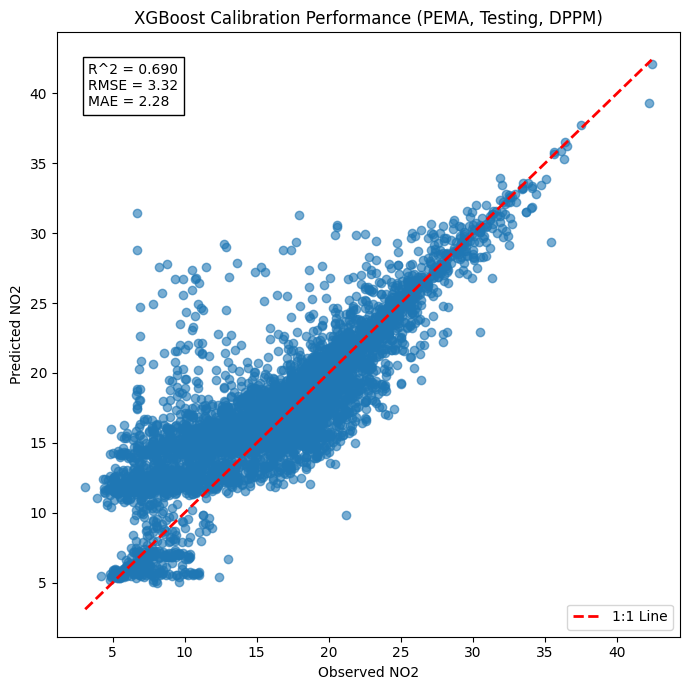

In [182]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="1:1 Line")

plt.xlabel("Observed NO2")
plt.ylabel("Predicted NO2")
plt.title("XGBoost Calibration Performance (PEMA, Testing, DPPM)")

plt.text(0.05, 0.95, f"R^2 = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}", transform=plt.gca().transAxes, verticalalignment="top", bbox=dict(facecolor="white"))

plt.legend()
plt.tight_layout()
plt.show()

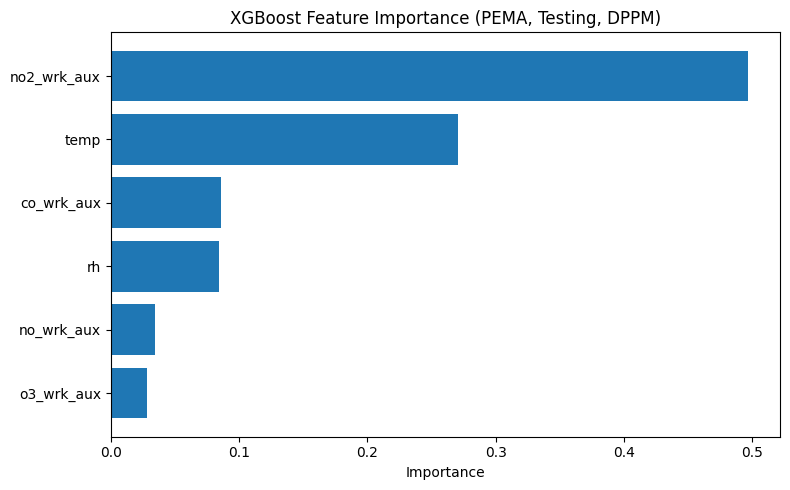

In [183]:
importance = pd.DataFrame({"feature": X_train.columns,"importance": model.feature_importances_})

importance = importance.sort_values(by="importance",ascending=True)

plt.figure(figsize=(8,5))

plt.barh(importance["feature"], importance["importance"])

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (PEMA, Testing, DPPM)")

plt.tight_layout()
plt.show()

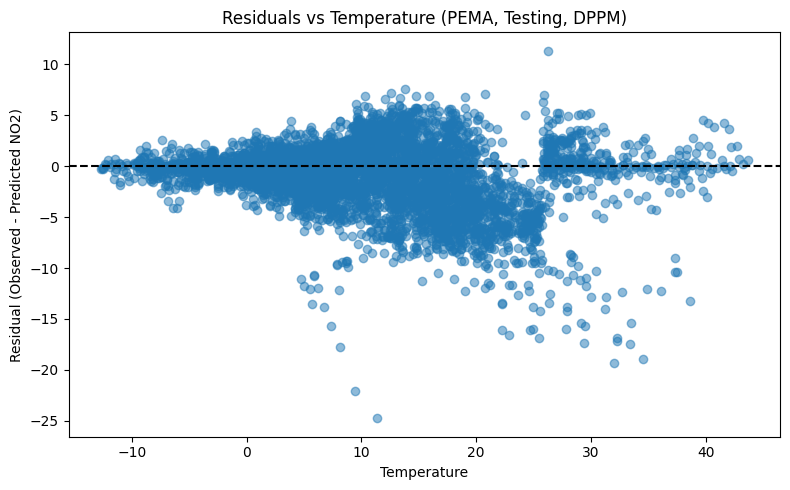

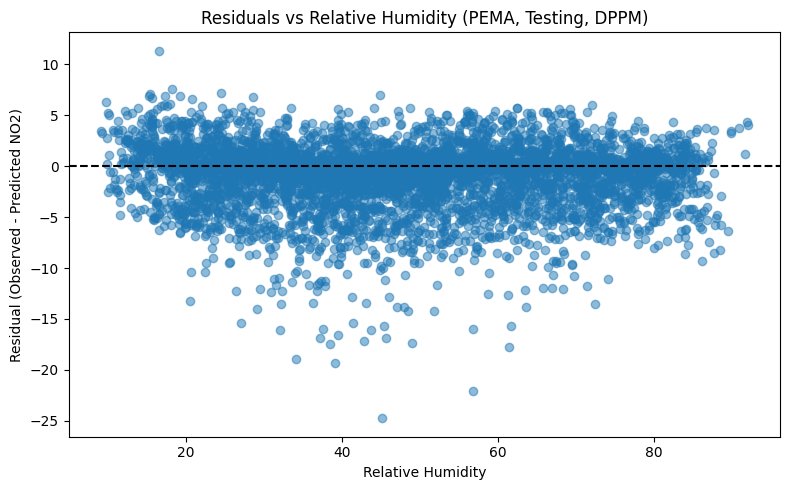

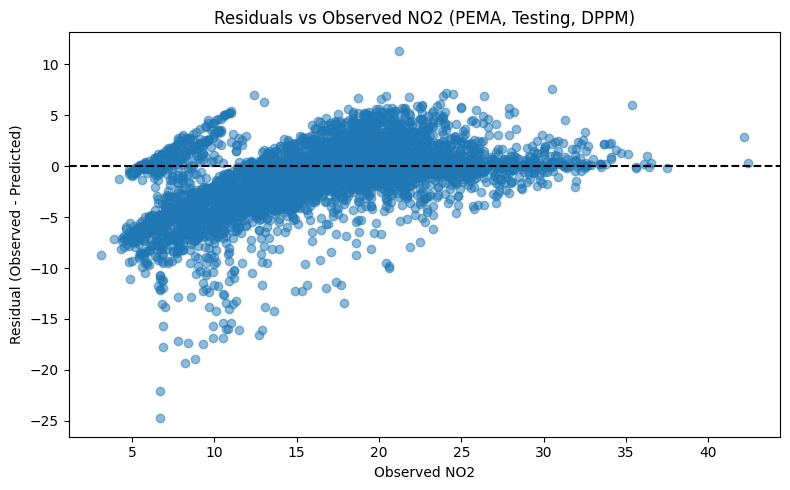

In [184]:
results = X_test.copy()

results["observed_no2"] = y_test.values
results["predicted_no2"] = y_pred

results["residual"] = results["observed_no2"] - results["predicted_no2"]

plt.figure(figsize=(8,5))

plt.scatter(results["temp"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Temperature")
plt.ylabel("Residual (Observed - Predicted NO2)")
plt.title("Residuals vs Temperature (PEMA, Testing, DPPM)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(results["rh"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Relative Humidity")
plt.ylabel("Residual (Observed - Predicted NO2)")
plt.title("Residuals vs Relative Humidity (PEMA, Testing, DPPM)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(results["observed_no2"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Observed NO2")
plt.ylabel("Residual (Observed - Predicted)")
plt.title("Residuals vs Observed NO2 (PEMA, Testing, DPPM)")

plt.tight_layout()
plt.show()

### PHA

In [185]:
pha_no2_train = pd.read_csv("ML ready dppm no2 datasets/pha_no2_train.csv")
pha_no2_train["datetime_utc"] = pd.to_datetime(pha_no2_train["datetime_utc"])
pha_no2_test = pd.read_csv("ML ready dpp no2 datasets/pha_no2_test.csv")
pha_no2_test["datetime_utc"] = pd.to_datetime(pha_no2_test["datetime_utc"])

In [186]:
predictor_cols = [
    "co_wrk_aux",
    "no2_wrk_aux",
    "no_wrk_aux",
    "o3_wrk_aux",
    "rh",
    "temp"
]

X_train = pha_no2_train[predictor_cols]
y_train = pha_no2_train["pha_quant_no2"]

In [187]:
model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_train)

In [188]:
r2 = r2_score(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)
rmse = np.sqrt(mean_squared_error(y_train, y_pred))

print(f"R^2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.9955
MAE: 0.2877
RMSE: 0.3816


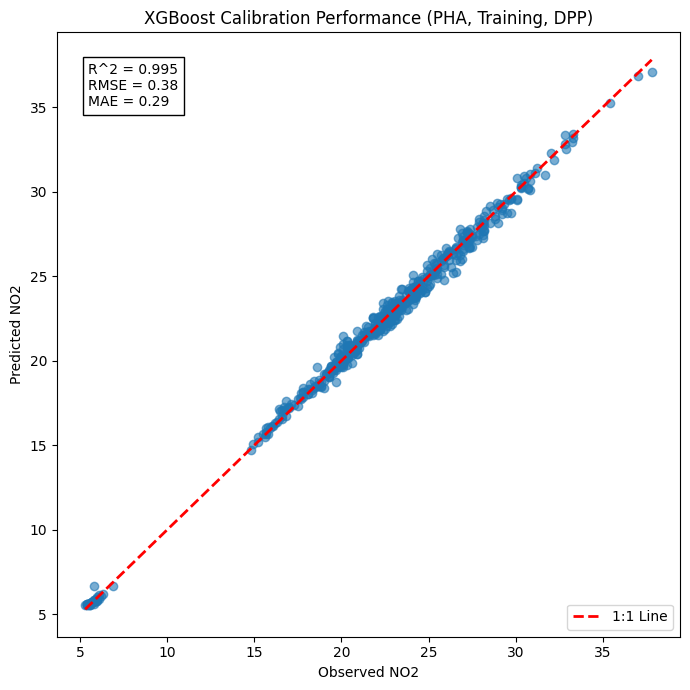

In [189]:
plt.figure(figsize=(7,7))

plt.scatter(y_train, y_pred, alpha=0.6)

min_val = min(y_train.min(), y_pred.min())
max_val = max(y_train.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="1:1 Line")

plt.xlabel("Observed NO2")
plt.ylabel("Predicted NO2")
plt.title("XGBoost Calibration Performance (PHA, Training, DPP)")

plt.text(0.05, 0.95, f"R^2 = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}", transform=plt.gca().transAxes, verticalalignment="top", bbox=dict(facecolor="white"))

plt.legend()
plt.tight_layout()
plt.show()

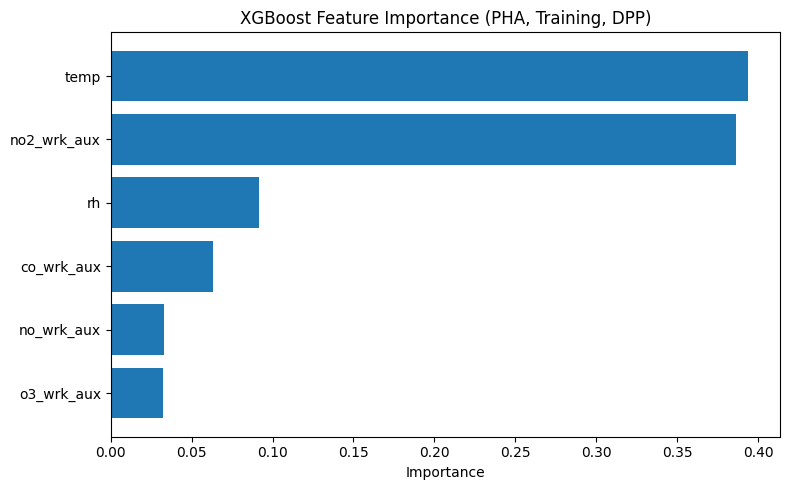

In [190]:
importance = pd.DataFrame({"feature": X_train.columns,"importance": model.feature_importances_})

importance = importance.sort_values(by="importance",ascending=True)

plt.figure(figsize=(8,5))

plt.barh(importance["feature"], importance["importance"])

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (PHA, Training, DPP)")

plt.tight_layout()
plt.show()

In [191]:
predictor_cols = [
    "co_wrk_aux",
    "no2_wrk_aux",
    "no_wrk_aux",
    "o3_wrk_aux",
    "rh",
    "temp"
]

X_test = pha_no2_test[predictor_cols]
y_test = pha_no2_test["pha_quant_no2"]

In [192]:
y_pred = model.predict(X_test)

In [193]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R^2: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.7377
MAE: 2.1506
RMSE: 3.3426


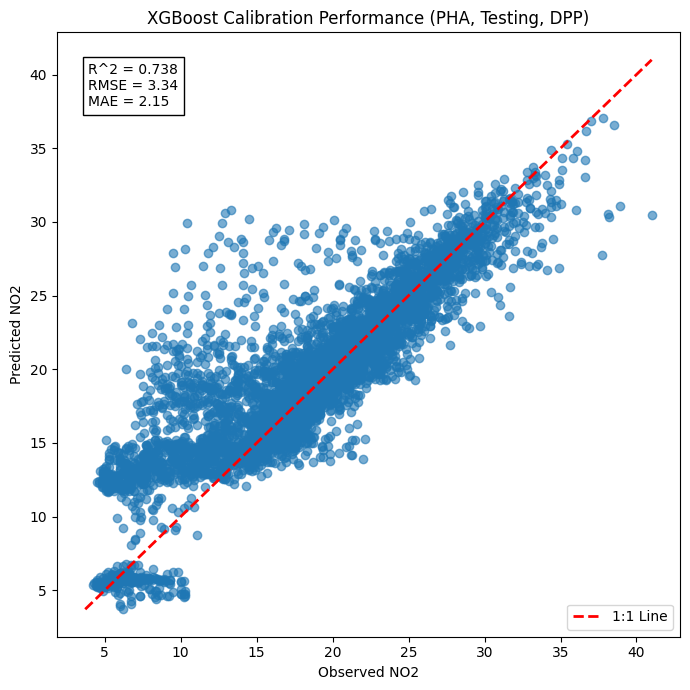

In [194]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.6)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="1:1 Line")

plt.xlabel("Observed NO2")
plt.ylabel("Predicted NO2")
plt.title("XGBoost Calibration Performance (PHA, Testing, DPP)")

plt.text(0.05, 0.95, f"R^2 = {r2:.3f}\nRMSE = {rmse:.2f}\nMAE = {mae:.2f}", transform=plt.gca().transAxes, verticalalignment="top", bbox=dict(facecolor="white"))

plt.legend()
plt.tight_layout()
plt.show()

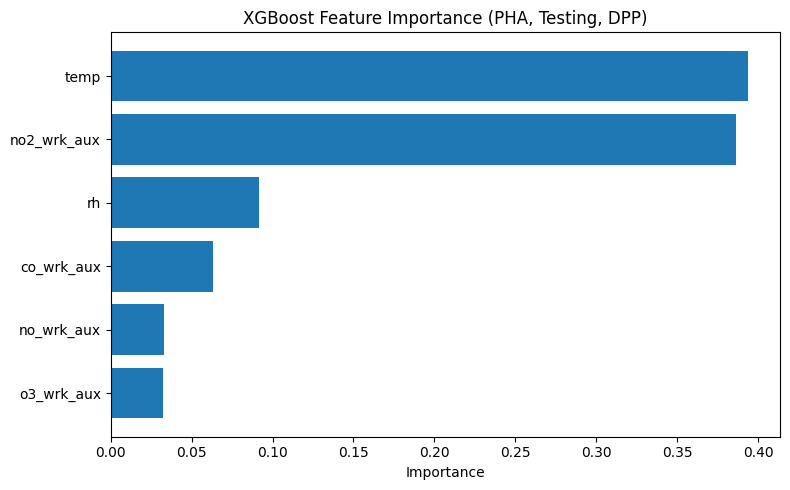

In [195]:
importance = pd.DataFrame({"feature": X_train.columns,"importance": model.feature_importances_})

importance = importance.sort_values(by="importance",ascending=True)

plt.figure(figsize=(8,5))

plt.barh(importance["feature"], importance["importance"])

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance (PHA, Testing, DPP)")

plt.tight_layout()
plt.show()

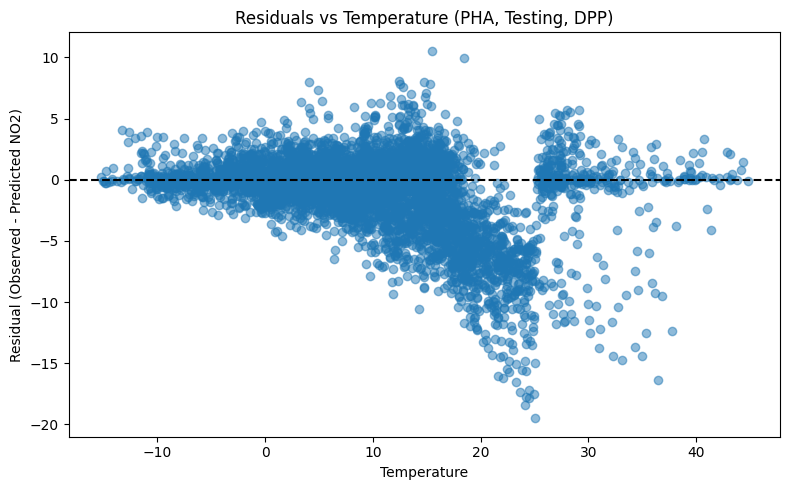

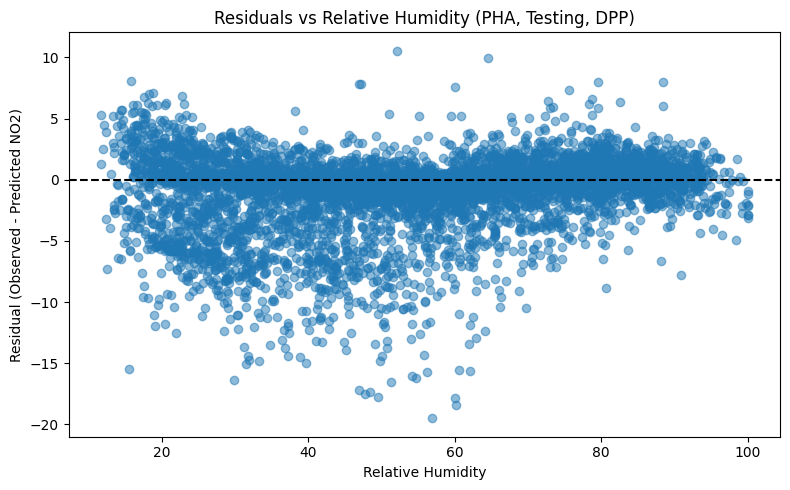

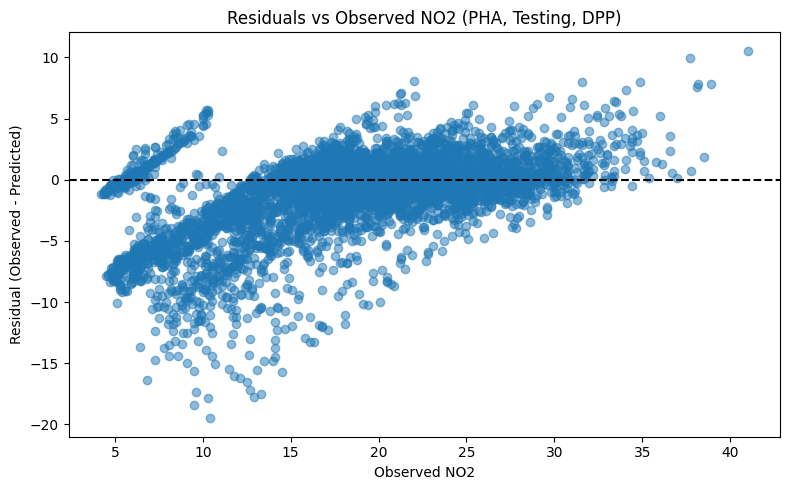

In [196]:
results = X_test.copy()

results["observed_no2"] = y_test.values
results["predicted_no2"] = y_pred

results["residual"] = results["observed_no2"] - results["predicted_no2"]

plt.figure(figsize=(8,5))

plt.scatter(results["temp"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Temperature")
plt.ylabel("Residual (Observed - Predicted NO2)")
plt.title("Residuals vs Temperature (PHA, Testing, DPP)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(results["rh"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Relative Humidity")
plt.ylabel("Residual (Observed - Predicted NO2)")
plt.title("Residuals vs Relative Humidity (PHA, Testing, DPP)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(results["observed_no2"], results["residual"], alpha=0.5)

plt.axhline(0, linestyle="--", color="black")

plt.xlabel("Observed NO2")
plt.ylabel("Residual (Observed - Predicted)")
plt.title("Residuals vs Observed NO2 (PHA, Testing, DPP)")

plt.tight_layout()
plt.show()